In [21]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
from typing import List
import csv
import matplotlib.pyplot as plt

# **A**. Implémentation de k-means séquentiel

## Sequential K-means:
- Generates synthetic data

- Implements incremental clustering

- Saves results and visualizes clustering

In [23]:
# Génération des données 
def generate_data():
    np.random.seed(42)  # Assurer la reproductibilité
    class_1 = np.random.normal(loc=5, scale=1.0, size=(100, 2))
    class_2 = np.random.normal(loc=10, scale=1.0, size=(100, 2))
    data = np.vstack((class_1, class_2))
    np.savetxt("data.csv", data, delimiter=",", header="x,y", comments="", fmt="%.6f")
    print("Data generated and saved to data.csv")

In [24]:

# Lecture des données en consommant peu de mémoire en utilisant un générateur
def read_data(file_path, chunksize=100):
    for chunk in pd.read_csv(file_path, chunksize=chunksize):
        yield chunk.to_numpy()


In [25]:

# Implémentation du K-Means séquentiel
def kmeans_sequential(file_path, k=2, max_iter=100, tolerance=1e-4):
    # Initialisation des centroids
    data_iterator = read_data(file_path, chunksize=10)
    centroids = next(data_iterator)[:k, :]
    
    assignments = []

    for iteration in range(max_iter):
        new_centroids = np.zeros_like(centroids)
        counts = np.zeros(k)
        assignments = []

        # Assigner à chaque point un centroids correspondant d'une maniére incrémentale
        for chunk in read_data(file_path):
            for point in chunk:
                distances = np.linalg.norm(point - centroids, axis=1)
                nearest_centroid_idx = np.argmin(distances)
                counts[nearest_centroid_idx] += 1
                new_centroids[nearest_centroid_idx] += (point - new_centroids[nearest_centroid_idx]) / counts[nearest_centroid_idx]
                assignments.append(nearest_centroid_idx)

        # Regarder la convergence 
        if np.all(np.abs(new_centroids - centroids) < tolerance):
            print(f"Convergence par itération {iteration}")
            break

        centroids = new_centroids

    # Sauvegarder les centroids
    np.savetxt("centroids.csv", centroids, delimiter=",", header="x,y", comments="", fmt="%.6f")
    print("Sauvegarder les centroids dans un fichier 'centroids.csv' ")
    return centroids, np.array(assignments)

In [26]:
# Visualisation des resultats
def visualize_results(file_path, centroids, assignments):
    data = np.loadtxt(file_path, delimiter=",", skiprows=1)
    
    # Assigné des couleurs à chaque classe
    colors = [ "orange","blue", "green", "purple", "pink"]
    for i in range(len(centroids)):
        cluster_points = data[assignments == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=10, color=colors[i % len(colors)], label=f"Classe {i}")
    plt.scatter(centroids[:, 0], centroids[:, 1], color="red", marker="x", s=100, label="Centroids")
    plt.legend()
    plt.title("Résultats K-means")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

Data generated and saved to data.csv
Convergence par itération 2
Sauvegarder les centroids dans un fichier 'centroids.csv' 


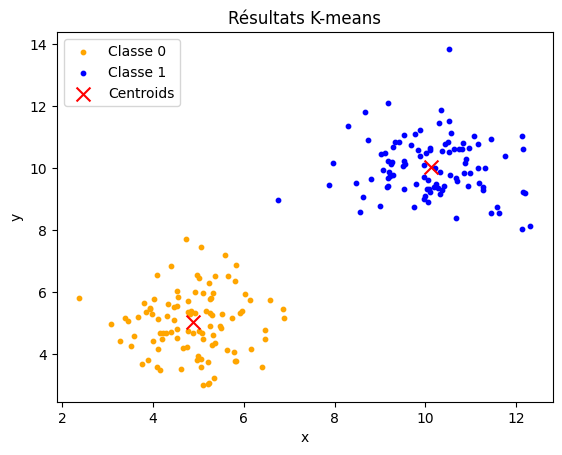

In [27]:
# Execution des fonctions
generate_data()
centroids, assignments = kmeans_sequential("data.csv", k=2)
visualize_results("data.csv", centroids, assignments)

# **B**. Implémentation d’une version streaming de k-means

- Implementation du streamingKMeans
- Simulation des données en Streaming
- Visualisation des résultats

In [28]:
class StreamingKMeans:
    def __init__(self, max_batches: int = 5, decay_rate: float = 0.5, n_clusters: int = 2):
        """
        Streaming K-means implementation with enhanced visualization support

        Parameters:
        max_batches (int): Maximum number of batches to retain
        decay_rate (float): Weight decay rate for historical batches
        n_clusters (int): Number of clusters
        """
        self.max_batches = max_batches
        self.decay_rate = decay_rate
        self.n_clusters = n_clusters
        self.batches = []  # Stocker les batches 
        self.centroids = None  # Stocker les centroids
        self.all_labels = None  # Stocker les labels
    
    def process_batch(self, batch: np.ndarray) -> np.ndarray:
        """
        Process a new batch of data and update centroids.

        Parameters:
        batch (numpy.ndarray): New data batch

        Returns:
        numpy.ndarray: Updated centroids
        """ 
        # l'historique de chaque batche
        if len(self.batches) == self.max_batches:
            self.batches.pop(0)
        self.batches.append(batch)
        
        # Ampilement des données de chaque batche avec vstack 
        all_data = np.vstack(self.batches)
        
        weights = np.repeat(
            [self.decay_rate ** t for t in range(len(self.batches))[::-1]],
            [len(batch) for batch in self.batches]
        )
        
        # Aplication du k-Means sur les poids
        kmeans = KMeans(n_clusters=self.n_clusters, n_init=10, random_state=42)
        kmeans.fit(all_data, sample_weight=weights)
        
        # Store labels for the entire dataset
        self.all_labels = kmeans.predict(all_data)
        
        self.centroids = kmeans.cluster_centers_
        return self.centroids


In [29]:

def simulate_streaming_data(n_batches: int = 10, batch_size: int = 50) -> List[np.ndarray]:
    """
    Simulate streaming data with concept drift.

    Parameters:
    n_batches (int): Number of batches to simulate
    batch_size (int): Number of points per batch

    Returns:
    List[np.ndarray]: Simulated data batches
    """
    np.random.seed(42)
    batches = []
    centers = [(5, 5), (10, 10)]
    
    for i in range(n_batches):
        # Introduce slight drift in cluster centers
        noise = np.random.uniform(-0.5, 0.5, (2, 2))
        drift = i * 0.1 * np.array([[1, 1], [-1, -1]])
        batch_centers = centers + drift + noise
        
        # Generate batch data
        batch = np.vstack([
            np.random.normal(loc=batch_centers[0], scale=1, size=(batch_size // 2, 2)),
            np.random.normal(loc=batch_centers[1], scale=1, size=(batch_size // 2, 2))
        ])
        batches.append(batch)
    
    return batches

In [30]:

def visualize_streaming_process(streaming_kmeans: StreamingKMeans, batches: List[np.ndarray]):
    """
    Visualize the streaming process dynamically with colored clusters.

    Parameters:
    streaming_kmeans (StreamingKMeans): The Streaming K-means instance
    batches (List[np.ndarray]): The streaming data batches
    """
    # Create a figure with subplots for each batch
    n_batches = len(batches)
    fig, axs = plt.subplots(nrows=(n_batches + 1) // 2, ncols=2, figsize=(16, 4 * ((n_batches + 1) // 2)))
    axs = axs.ravel()  # Flatten the axes array for easy indexing
    
    # Color palette for clusters
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    
    for i, batch in enumerate(batches):
        # Process the batch
        centroids = streaming_kmeans.process_batch(batch)
        print(f"centroids à l'iteration {i+1}:\n{centroids}")
        # Get all data accumulated so far
        all_data = np.vstack(streaming_kmeans.batches)
        
        # Get labels for all data points
        labels = streaming_kmeans.all_labels
        
        # Plot on the corresponding subplot
        ax = axs[i]
        ax.clear()
        # Plot data points with cluster-specific colors
        for cluster in range(streaming_kmeans.n_clusters):
            cluster_mask = labels == cluster
            ax.scatter(
                all_data[cluster_mask, 0], 
                all_data[cluster_mask, 1], 
                c=colors[cluster % len(colors)], 
                label=f'Cluster {cluster}', 
                alpha=0.7
            )
        
        # Plot centroids
        ax.scatter(
            centroids[:, 0], 
            centroids[:, 1], 
            c='black', 
            marker='x', 
            s=200, 
            linewidths=3, 
            label='Centroids'
        )
        
        # Formatting
        ax.set_title(f"Iteration {i+1}")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.legend()
        ax.grid(True)
    
    # Remove any unused subplots
    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])
    
    plt.tight_layout()
    plt.show()

centroids à l'iteration 1:
[[ 4.63485912  5.13323101]
 [10.08422416 10.16779945]]
centroids à l'iteration 2:
[[ 5.1761354   5.07811904]
 [ 9.92705913 10.27538421]]
centroids à l'iteration 3:
[[10.06936044  9.84225256]
 [ 5.45824249  5.51650439]]
centroids à l'iteration 4:
[[9.9752173  9.9948464 ]
 [5.59853752 5.35099404]]
centroids à l'iteration 5:
[[9.76409772 9.8425644 ]
 [5.29360604 5.409478  ]]
centroids à l'iteration 6:
[[9.76237818 9.57910753]
 [5.57219708 5.35208939]]
centroids à l'iteration 7:
[[9.37036883 9.74612111]
 [5.45460639 5.49929976]]
centroids à l'iteration 8:
[[9.33357032 9.38435577]
 [5.86156573 5.63302467]]
centroids à l'iteration 9:
[[9.34131641 9.34418772]
 [5.83199058 5.80261441]]
centroids à l'iteration 10:
[[9.51114693 9.04110103]
 [5.68878577 6.03983624]]


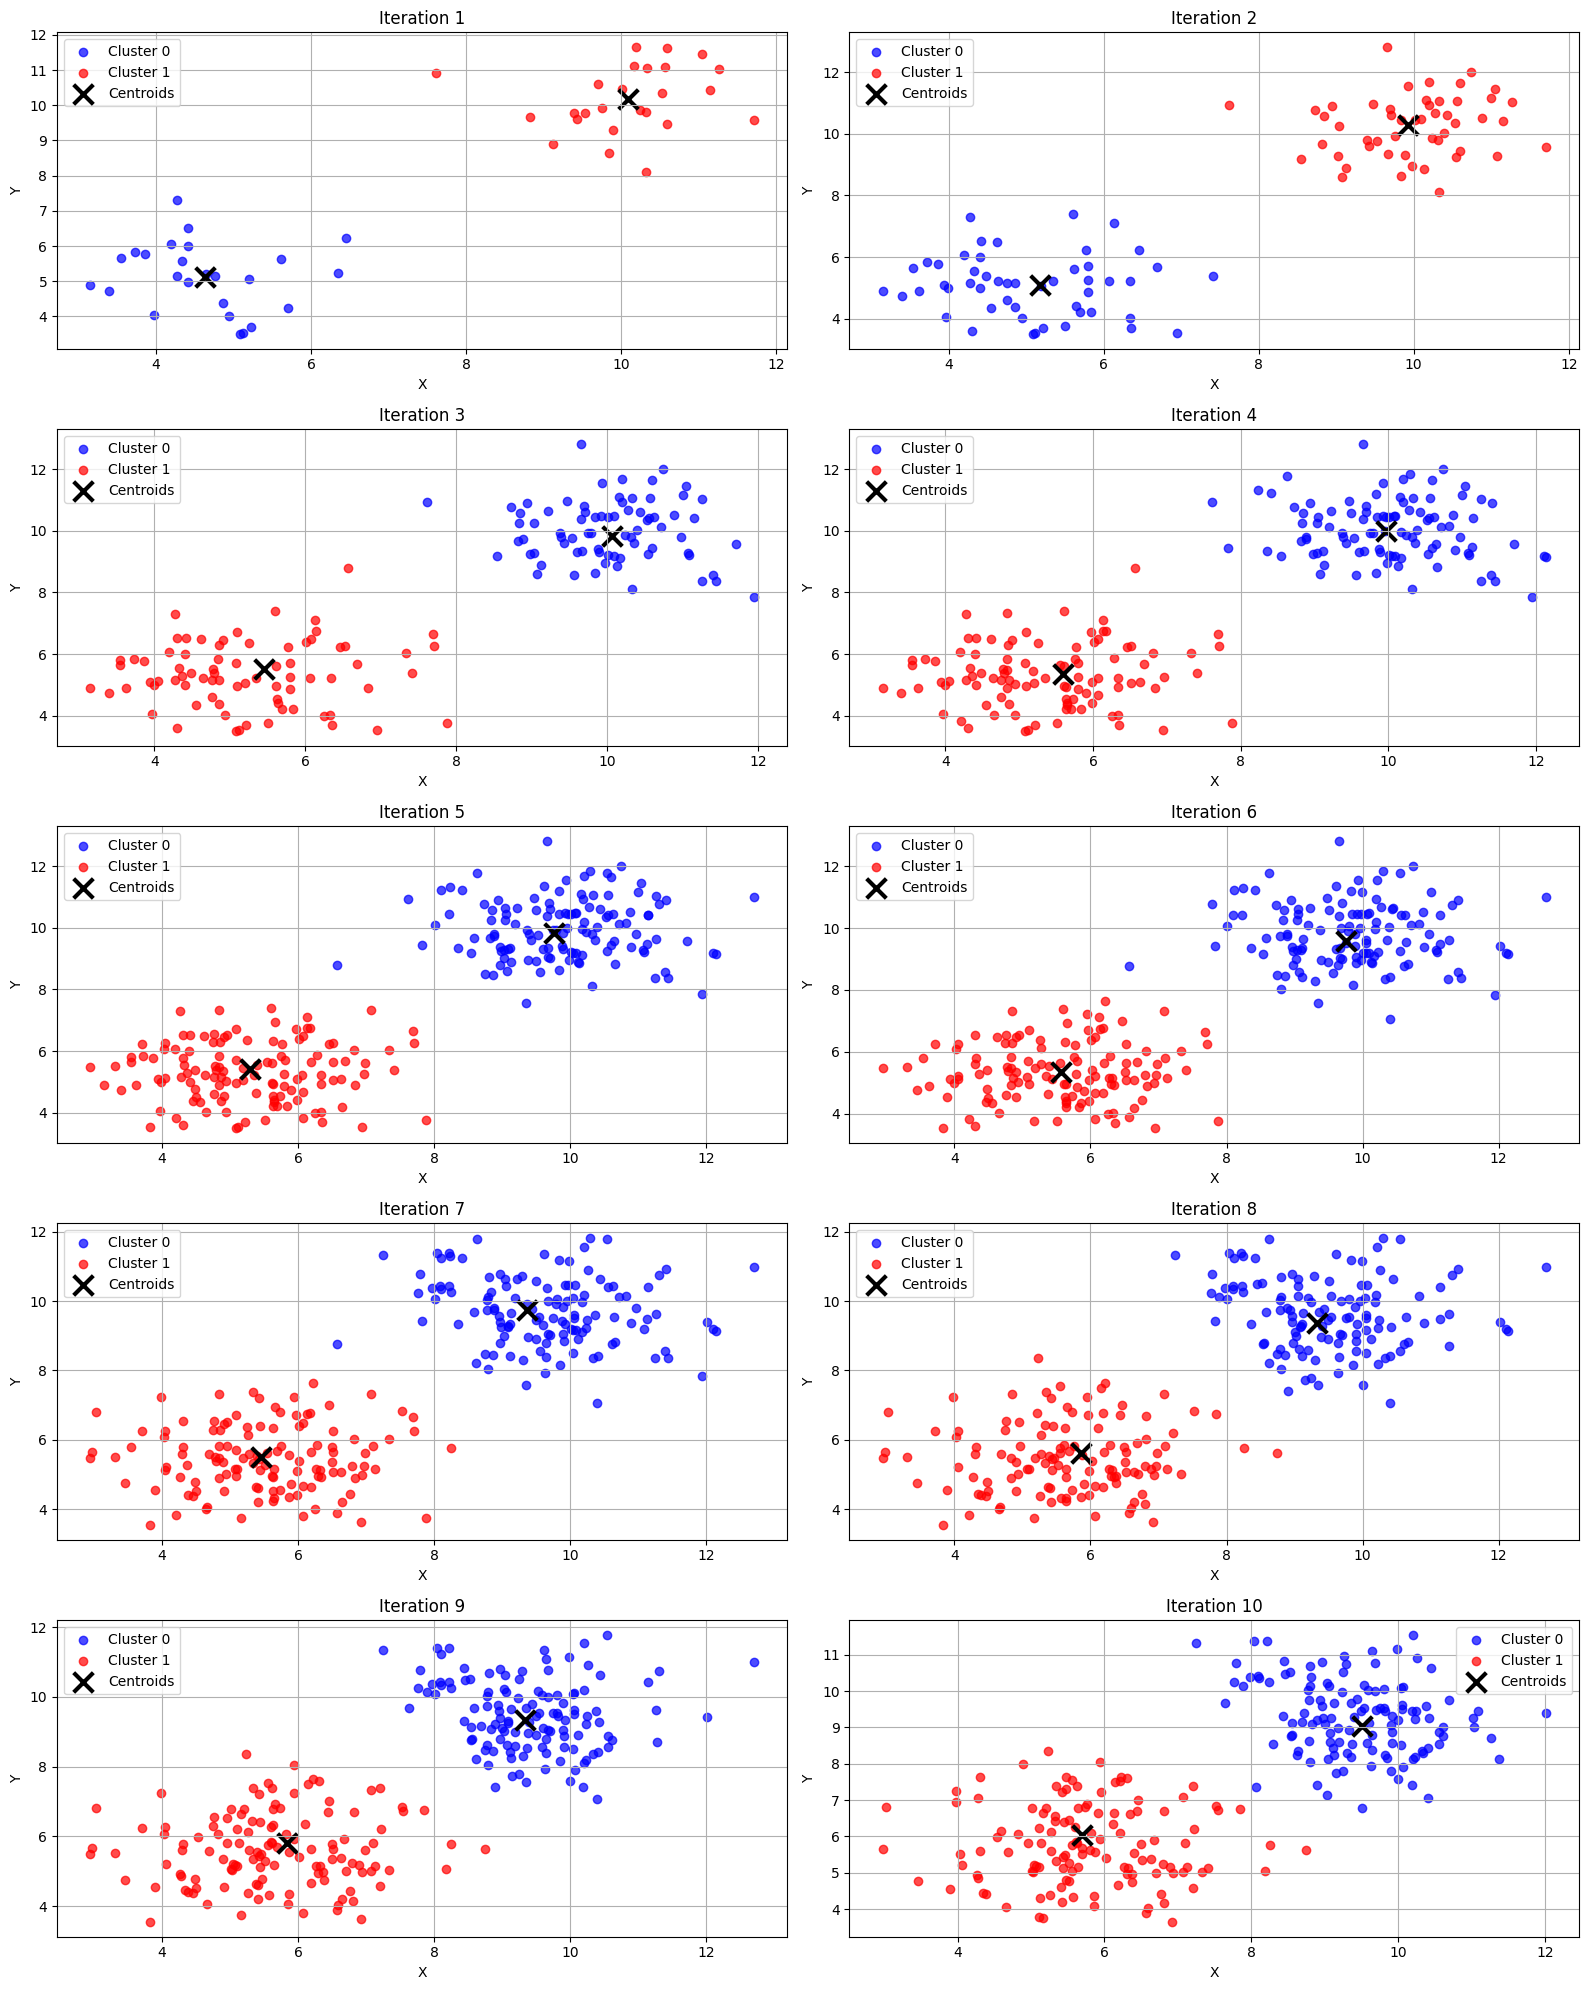

In [31]:

def main():
    # Simulate streaming data
    batches = simulate_streaming_data()
    # Initialize StreamingKMeans
    streaming_kmeans = StreamingKMeans()
    # Visualize the streaming process
    visualize_streaming_process(streaming_kmeans, batches)

if __name__ == "__main__":
    main()

# C. Implémentation de k-means distribué(Apache Beam)

In [5]:
! pip install apache_beam -q

In [6]:
import apache_beam as beam
import random
import math
from apache_beam.options.pipeline_options import PipelineOptions

## Points

In [7]:
points= [(1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12), (13, 14), (15, 16)]

## PCollection

In [8]:
with beam.Pipeline() as pipeline:
    pcollections_points =(
        pipeline | "Create Points" >> beam.Create(points)
    ) 
    pcollections_points | "Afficher les points" >> beam.Map(print)

(1, 2)
(3, 4)
(5, 6)
(7, 8)
(9, 10)
(11, 12)
(13, 14)
(15, 16)


## Assigner chaque point à un cluster

In [9]:
# Nombre de clusters
k = 2
def assign_random_cluster(points, num_clusters):
    id_cluster= random.randint(0, num_clusters - 1)
    return id_cluster, points

with beam.Pipeline() as pipeline:
    pcollections_points =(
        pipeline | "Create Points" >> beam.Create(points)
    ) 
    #pcollections_points | "Afficher les points" >> beam.Map(print)
    cluster= (
        pcollections_points | "Assigner chaque points un cluster" >> beam.Map(assign_random_cluster,k )
        | "Grouper les points en fonction du cluster" >> beam.GroupByKey()
    )
    cluster | "Afficher les points avec le cluster associé" >> beam.Map(print)



(1, [(1, 2), (3, 4), (5, 6), (9, 10), (11, 12), (13, 14), (15, 16)])
(0, [(7, 8)])


## Centroides

In [10]:
def campute_centroids(points_clusters):
    clusters_id, list_points= points_clusters
    length= len(list_points)
    centroids_x= sum(x[0] for x in list_points)/length
    centroids_y= sum(y[1] for y in list_points)/length
    return clusters_id, (centroids_x, centroids_y)


with beam.Pipeline() as pipeline:
    pcollections_points =(
        pipeline | "Create Points" >> beam.Create(points)
    ) 
    #pcollections_points | "Afficher les points" >> beam.Map(print)

    cluster= (
        pcollections_points | "Assigner chaque points un cluster" >> beam.Map(assign_random_cluster,k )
        | "Grouper les points en fonction du cluster" >> beam.GroupByKey()
    )
    cluster | "Afficher les points avec le cluster associé" >> beam.Map(print)

    
    centoids_clusters= (
        cluster | " \n Centroids de chaque cluster" >> beam.Map(campute_centroids)
    )
    centoids_clusters | "Afficher les centroides de chaque cluster" >> beam.Map(print)

(1, (8.0, 9.0))
(1, [(1, 2), (7, 8), (11, 12), (13, 14)])
(0, (8.0, 9.0))
(0, [(3, 4), (5, 6), (9, 10), (15, 16)])


## Implémentation de l'étape partitionnement 

### assign_cluster

In [19]:

def assign_cluster(point, centroides):
    """
    Associe un point au cluster le plus proche.

    Args:
        point (tuple): Les coordonnées du point (x, y).
        centroids (dict): Dictionnaire des centroïdes {cluster_id: (centroid_x, centroid_y)}.

    Returns:
        tuple: (cluster_id, point) où cluster_id est le numéro du cluster le plus proche.
    """
    closest_cluster = None
    min_distance=float("inf")
    for cluster_id, centoids in centroides.items():
        # Calcul de la distance euclidienne
        distance = math.sqrt( (point[0] - centoids[0])**2 + (point[1] - centoids[1])**2 )
        if distance < min_distance:
            min_distance = distance
            closest_cluster= cluster_id
    return closest_cluster, point

In [21]:
centroids = {
    0: (1, 1),
    1: (5, 5),
    2: (10, 10)
}
point = (1, 1)
result = assign_cluster(point, centroids)
print(result)


(0, (1, 1))


In [ ]:
# Données de test
points= [(1,1), (2, 2), (6, 6), (7,7), (9, 9),(11,11)]
# Je donne une liste de centroids avec coordonnées

centroids = {0: (1, 1), 1: (5, 5), 2: (10, 10)}

with beam.Pipeline() as pipeline:
    pcollection_points =(
        pipeline | "Create Points" >> beam.Create(points)
    )
    #pcollection_points | "Affiches points" >> beam.Map(print)
    
    pcollection_centroids= (
        pipeline | "Create Centroids" >> beam.Create([centroids])
    )
    #pcollection_centroids | "afficher centroids" >> beam.Map(print)

    # Assigner à chaque point au cluster le plus proche
    assigned_points = (
        pcollection_points
        | "Assign Closest Cluster" >> beam.Map(
            assign_cluster, 
            centroides=beam.pvalue.AsSingleton(pcollection_centroids)
        )
    ) 
    # Afficher les points assignés
    assigned_points | "Afficher cluster et point" >> beam.Map(print)

(0, (1, 1))
(0, (2, 2))
(1, (6, 6))
(1, (7, 7))
(2, (9, 9))
(2, (11, 11))


In [33]:
# Points d'entrée
points = [(1, 1), (2, 2), (4, 3), (3, 3), (6, 6), (7, 7), (9, 9), (2, 10), (10, 2), (11, 11)]
k = 2  # Nombre de clusters

# Pipeline Apache Beam
with beam.Pipeline() as pipeline:
    # 1. Créer une PCollection des points
    pcollections_points = pipeline | "Create Points" >> beam.Create(points)

    # 2. Associer chaque point à un cluster aléatoire
    clusters = (
        pcollections_points
        | "Assign Random Clusters" >> beam.Map(assign_random_cluster, k)
        | "Group by Cluster" >> beam.GroupByKey()
    )

    # 3. Calculer les centroïdes
    centroids = (
        clusters
        | "Compute Centroids" >> beam.Map(campute_centroids)
        | "Centroids to Dict" >> beam.transforms.combiners.ToDict()
    )
    # entroids | "Print centroids Points" >> beam.Map(print)
    # Assigner à chaque point au cluster le plus proche
    assigned_points = (
        pcollections_points
        | "Assign Closest Cluster" >> beam.Map(
            assign_cluster, 
            centroides=beam.pvalue.AsSingleton(centroids)
        )
        | "Commbiner par cluster" >> beam.GroupByKey()
    ) 
    assigned_points | " Print Assigned Points" >> beam.Map(print)

(1, [(1, 1), (2, 2), (4, 3), (3, 3), (10, 2)])
(0, [(6, 6), (7, 7), (9, 9), (2, 10), (11, 11)])


### Les suppositions principales sont :

- Ils sont connus à l'avance.

- On considére qu'ils sont statiques.

- Il peuvent tenir en mémoire.

# D. Implémentation de k-means séquentiel distribuée (Apache Beam)

In [3]:
def generate_data():
    np.random.seed(42)  # Assurer la reproductibilité
    class_1 = np.random.normal(loc=5, scale=1.0, size=(100, 2))
    class_2 = np.random.normal(loc=10, scale=1.0, size=(100, 2))
    data = np.vstack((class_1, class_2))
    np.savetxt("data.csv", data, delimiter=",", header="x,y", comments="", fmt="%.6f")
    print("Data generated and saved to data.csv")

In [33]:
# J'assigne à chaque poin un random cluster
def csv_random_cluster(line):
    x,y = map(float, line.split(','))
    return np.random.randint(0, 2), (x, y)

2

In [37]:
# K-Means distribué
class KMeansDistributed(beam.DoFn):
    # Je définis l'état des centroids
    centoids_state= BagStateSpec(name='centroids', coder=beam.coders.PickleCoder())
    count_state= BagStateSpec(name='counts', coder= beam.coders.PickleCoder())

    def process(self, element, centroids= beam.DoFn.StateParam(centoids_state), counts= beam.DoFn.StateParam(count_state)):
        cluster_id, point= element
        current_centroids= list(centroids.read())
        current_counts= list(counts.read())
        if not current_centroids or not current_counts:
            centroids.add(point)
            counts.add(1)
            yield cluster_id, (point, 1)
            return

        centroid = np.array(current_centroids[0])
        count = current_counts[0]

        new_centroid = ((centroid * count) + np.array(point)) / (count + 1)
        centroids.clear()
        counts.clear()
        centroids.add(tuple(new_centroid))
        counts.add(count + 1)

        yield cluster_id, (tuple(new_centroid),count + 1)

# Main Function
def run_pipeline():
    with beam.Pipeline() as pipeline:
        # Read data from CSV
        data = (
            pipeline
            | "Read Data" >> beam.io.ReadFromText("data.csv", skip_header_lines=1)
            | "Parse Data" >> beam.Map(csv_random_cluster)
        )

        # Apply K-Means Update
        results = (
            data
            | "K-Means Update" >> beam.ParDo(KMeansDistributed())
            | "Print Results" >> beam.Map(print)
        )

# Generate Data and Run the Pipeline
if __name__ == '__main__':
    generate_data()
    run_pipeline()


Data generated and saved to data.csv
(0, ((5.496714, 4.861736), 1))
(0, ((5.5722015, 5.6923829999999995), 2))
(0, ((5.303416666666667, 5.3835429999999995), 3))
(0, ((5.62236575, 5.479515999999999), 4))
(1, ((4.530526, 5.54256), 1))
(0, ((5.405209, 5.290466799999999), 5))
(1, ((4.886244, 4.31464), 2))
(1, ((4.349189999999999, 4.355664), 3))
(0, ((5.168869, 5.2944301666666655), 6))
(0, ((5.015027142857143, 5.050610999999999), 7))
(0, ((5.196354875, 5.016062625), 8))
(0, ((5.182040777777778, 4.855972555555556), 9))
(1, ((4.375796749999999, 4.54447875), 4))
(0, ((5.048737300000001, 4.9079451), 10))
(0, ((4.989703090909091, 4.8897960909090905), 11))
(0, ((4.940418916666667, 5.05333625), 12))
(0, ((4.9439638461538475, 4.9678710769230765), 13))
(0, ((5.006719642857144, 4.882962857142857), 14))
(0, ((5.020195933333335, 4.7601206666666664), 15))
(1, ((4.2350002, 4.674955199999999), 5))
(1, ((4.485578, 4.757690666666666), 6))
(0, ((5.011705687500001, 4.756294125), 16))
(0, ((4.924045235294119, 4